<a href="https://colab.research.google.com/github/sj-workbench/years_of_learnings/blob/main/functiontransformer_log.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# In this i have worked on function transformer.
# In this dataset i have used Log Transform.
# One thing i learnt extra in this was Using .ravel() can convert any dimension into 1D.

In [ ]:
import numpy as np
import pandas as pd

import scipy.stats as stats  # for Q-Q plot

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer  #Function Transformer
from sklearn.compose import ColumnTransformer

In [ ]:
df = pd.read_csv('/content/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.drop(columns = ['PassengerId','Embarked','Pclass','Name','Sex','SibSp','Parch','Ticket','Cabin'],axis=1,inplace=True)
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [ ]:
df['Age'].fillna(df['Age'].mean(),inplace=True)  # replace the missing value of age with its mean

/tmp/ipykernel_2078/323122189.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)  # replace the missing value of age with its mean


In [ ]:
df.isnull().sum()

,0
Survived,0
Age,0
Fare,0


In [ ]:
x = df.iloc[:,1:3]
y = df.iloc[:,-3]

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
y_test.shape

(179,)

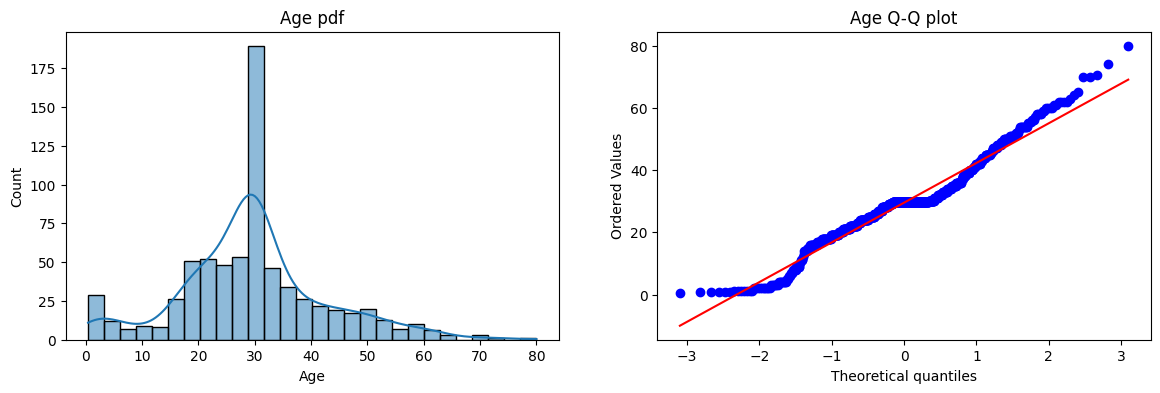

In [ ]:
# checking age distribution
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(x_train['Age'], kde=True)  #displot creates its own plot ignoring plt.subplot()
plt.title('Age pdf')

plt.subplot(122)
stats.probplot(x_train['Age'], dist='norm', plot=plt)
plt.title('Age Q-Q plot')

plt.show()

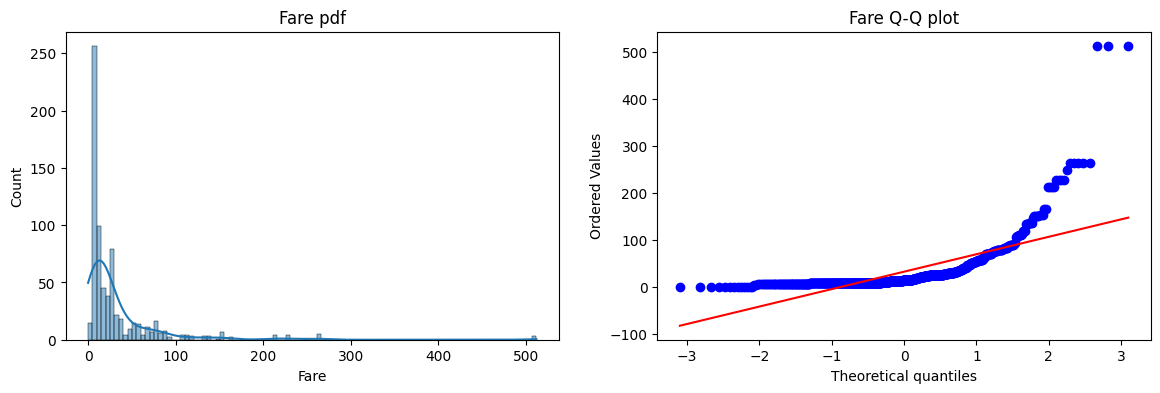

In [ ]:
# checking fare distribution
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(x_train['Fare'], kde=True)  #displot creates its own plot ignoring plt.subplot()
plt.title('Fare pdf')

plt.subplot(122)
stats.probplot(x_train['Fare'], dist='norm', plot=plt)
plt.title('Fare Q-Q plot')

plt.show()

In [ ]:
clf= LogisticRegression()
clf1= DecisionTreeClassifier()

In [ ]:
clf.fit(x_train,y_train)
clf1.fit(x_train,y_train)

y_pred= clf.predict(x_test)
y_pred1= clf1.predict(x_test)

print("Accuracy of LR: ", accuracy_score(y_pred,y_test))
print("Accuracy of DTC: ", accuracy_score(y_pred1,y_test))

Accuracy of LR:  0.6480446927374302
Accuracy of DTC:  0.6703910614525139


In [ ]:
# predicting using function transformer (log transform in this case)
# transformation on age and fare both
trf = FunctionTransformer(func = np.log1p)
x_train_transform = trf.fit_transform(x_train)
x_test_transform = trf.transform(x_test)

In [ ]:
clf2 = LogisticRegression()
clf3 = DecisionTreeClassifier()

clf2.fit(x_train_transform,y_train)
clf3.fit(x_train_transform,y_train)

y_pred2 = clf2.predict(x_test_transform)
y_pred3 = clf3.predict(x_test_transform)

print("Accuracy of LR: ", accuracy_score(y_pred2,y_test))
print("Accuracy of DTC: ", accuracy_score(y_pred3,y_test))

Accuracy of LR:  0.6815642458100558
Accuracy of DTC:  0.6759776536312849


In [ ]:
# using cross validation
x_tranform = trf.fit_transform(x)
clf4 = LogisticRegression()
clf5 = DecisionTreeClassifier()

print("Accuracy of LR: ", cross_val_score(clf4,x_tranform,y,scoring = 'accuracy',cv=5).mean())
print("Accuracy of DTC: ", cross_val_score(clf5,x_tranform,y,scoring = 'accuracy',cv=5).mean())

Accuracy of LR:  0.6780114242671521
Accuracy of DTC:  0.6453455526960015


In [ ]:
# comparison to check any improvement in the model (QQplot)

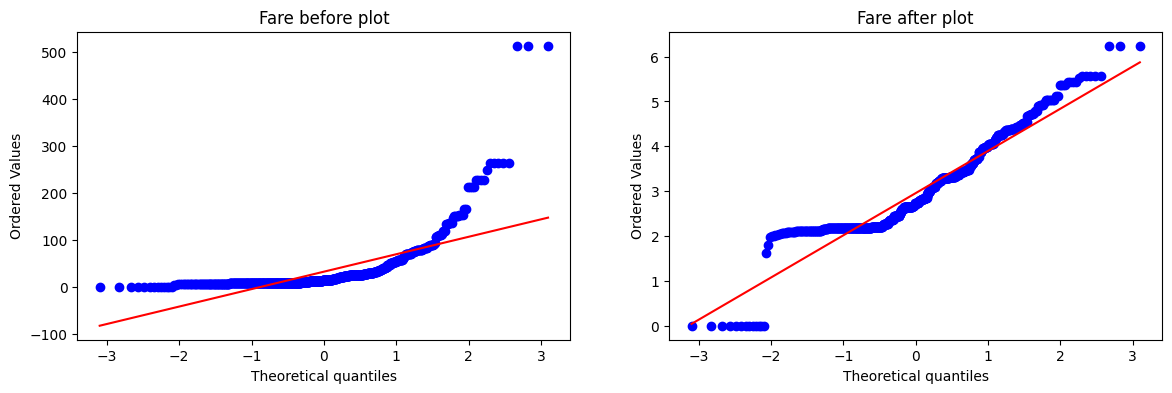

In [ ]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(x_train['Fare'], dist='norm', plot=plt)
plt.title('Fare before plot')

plt.subplot(122)
stats.probplot(x_train_transform['Fare'], dist='norm', plot=plt)
plt.title('Fare after plot')

plt.show()

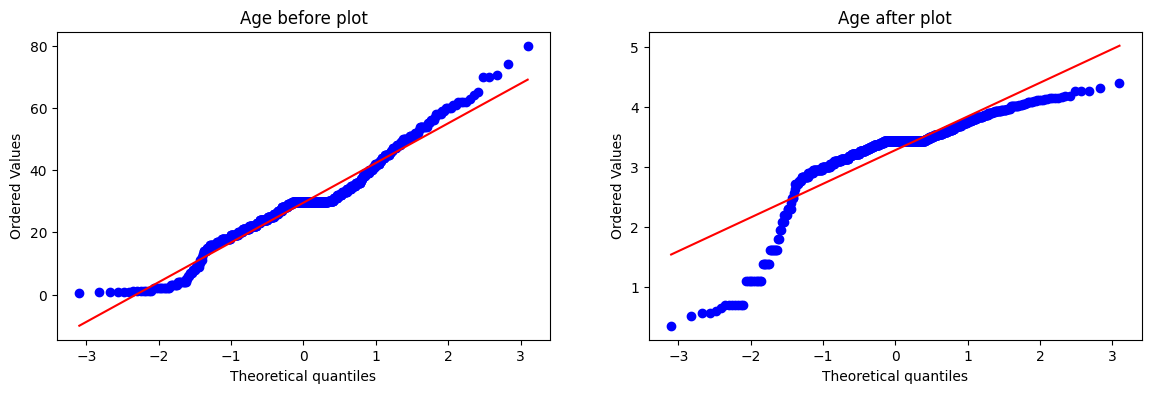

In [ ]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(x_train['Age'], dist='norm', plot=plt)
plt.title('Age before plot')

plt.subplot(122)
stats.probplot(x_train_transform['Age'], dist='norm', plot=plt)
plt.title('Age after plot')

plt.show()

In [ ]:
# in this we can see age got worse instead of improvement

In [ ]:
# in this we are keeping age the same but transforming fare
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder = 'passthrough')
x_trans2_train = trf2.fit_transform(x_train)
x_trans2_test = trf2.transform(x_test)

In [ ]:
clf = LogisticRegression()
clf2= DecisionTreeClassifier()

clf.fit(x_trans2_train,y_train)
clf2.fit(x_trans2_train,y_train)

y_pred = clf.predict(x_trans2_test)
y_pred1 = clf2.predict(x_trans2_test)
print("Accuracy of LR: ", accuracy_score(y_pred,y_test))
print("Accuracy of DTC: ", accuracy_score(y_pred1,y_test))

Accuracy of LR:  0.6703910614525139
Accuracy of DTC:  0.6703910614525139


In [ ]:
# performing cross validation
x_tranform2 = trf2.fit_transform(x)
clf0 = LogisticRegression()
clf1 = DecisionTreeClassifier()

print("Accuracy of LR: ", cross_val_score(clf0,x_tranform2,y,scoring = 'accuracy',cv=5).mean())
print("Accuracy of DTC: ", cross_val_score(clf1,x_tranform2,y,scoring = 'accuracy',cv=5).mean())

Accuracy of LR:  0.6712635741635804
Accuracy of DTC:  0.6464754252714833
